# Explore our dataset: Facebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read data into a DataFrame

* Looks like CSV is separated by colons instead of commas.
* Let's adjust our `pd.read_csv()` call.

In [2]:
df = pd.read_csv('../data/facebook.csv')
df

,Page total likes;Type;Category;Post Month;Post Weekday;Post Hour;Paid;Lifetime Post Total Reach;Lifetime Post Total Impressions;Lifetime Engaged Users;Lifetime Post Consumers;Lifetime Post Consumptions;Lifetime Post Impressions by people who have liked your Page;Lifetime Post reach by people who like your Page;Lifetime People who have liked your Page and engaged with your post;comment;like;share;Total Interactions
0,139441;Photo;2;12;4;3;0;2752;5091;178;109;159;...
1,139441;Status;2;12;3;10;0;10460;19057;1457;136...
2,139441;Photo;3;12;3;3;0;2413;4373;177;113;154;...
3,139441;Photo;2;12;2;10;1;50128;87991;2211;790;...
4,139441;Photo;2;12;2;3;0;7244;13594;671;410;580...
...,...
495,85093;Photo;3;1;7;2;0;4684;7536;733;708;985;47...
496,81370;Photo;2;1;5;8;0;3480;6229;537;508;687;39...
497,81370;Photo;1;1;5;2;0;3778;7216;625;572;795;47...
498,81370;Photo;3;1;4;11;0;4156;7564;626;574;832;4...


* Much better now

In [3]:
df = pd.read_csv('../data/facebook.csv', delimiter=';')
df

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,85093,Photo,3,1,7,2,0.0,4684,7536,733,708,985,4750,2876,392,5,53.0,26.0,84
496,81370,Photo,2,1,5,8,0.0,3480,6229,537,508,687,3961,2104,301,0,53.0,22.0,75
497,81370,Photo,1,1,5,2,0.0,3778,7216,625,572,795,4742,2388,363,4,93.0,18.0,115
498,81370,Photo,3,1,4,11,0.0,4156,7564,626,574,832,4534,2452,370,7,91.0,38.0,136


## Adjust column names

### Column names - Before

In [4]:
df.columns.to_list()

['Page total likes',
 'Type',
 'Category',
 'Post Month',
 'Post Weekday',
 'Post Hour',
 'Paid',
 'Lifetime Post Total Reach',
 'Lifetime Post Total Impressions',
 'Lifetime Engaged Users',
 'Lifetime Post Consumers',
 'Lifetime Post Consumptions',
 'Lifetime Post Impressions by people who have liked your Page',
 'Lifetime Post reach by people who like your Page',
 'Lifetime People who have liked your Page and engaged with your post',
 'comment',
 'like',
 'share',
 'Total Interactions']

### Column names - After

In [5]:
df.columns = [
    'page_likes',
    'post_type',
    'post_category',
    'post_month',
    'post_weekday',
    'post_hour',
    'paid_post',
    'total_reach',
    'total_impressions',
    'total_engaged_users',
    'consumers',
    'consumptions',
    'impressions_by_page_likers',
    'reach_by_page_likers',
    'page_likers_who_engaged_with_post',
    'interacted_with_comment',
    'interacted_with_like',
    'interacted_with_share',
    'total_interactions',
]
list(enumerate(df.columns.to_list()))

[(0, 'page_likes'),
 (1, 'post_type'),
 (2, 'post_category'),
 (3, 'post_month'),
 (4, 'post_weekday'),
 (5, 'post_hour'),
 (6, 'paid_post'),
 (7, 'total_reach'),
 (8, 'total_impressions'),
 (9, 'total_engaged_users'),
 (10, 'consumers'),
 (11, 'consumptions'),
 (12, 'impressions_by_page_likers'),
 (13, 'reach_by_page_likers'),
 (14, 'page_likers_who_engaged_with_post'),
 (15, 'interacted_with_comment'),
 (16, 'interacted_with_like'),
 (17, 'interacted_with_share'),
 (18, 'total_interactions')]

## Helpful definitions related the social media marketing

Given that this dataset is focused on social media marketing and includes jargon specific to that field, I found it helpful to look up the following definitions. The research paper also had the following figure which confirmed these definitions.

* **Reach** is "a metric that represents the number of unique people that were exposed and saw a piece of social media content." ([source: buffer.com][1])
* **Impressions** "refer to the number of times your social media content is displayed on someone’s screen." ([source: buffer.com][2])
* **Engagement** is "the total number of likes, comments, shares, and other interactions." ([source: buffer.com][3])
* **Comsumers** and **Consumptions** refer to "the process by which individuals engage with various forms of media." ([source: fivable.me][4])

![image](../docs/3-Table2-1.png)

[1]: https://buffer.com/social-media-terms/reach
[2]: https://buffer.com/social-media-terms/impressions
[4]: https://buffer.com/social-media-terms/engagement-rate
[3]: https://fiveable.me/key-terms/media-literacy/media-consumption

## Check for missing data or format issues


### Missing data

* From the output of `df.info()` below, it looks like three columns have tiny bit of missing data.
* Those columns are: `paid_post`, `interacted_with_like`, and `interacted_with_share`.
* Dropping the rows missing values is an option, but what how much data would we lose?
* By summing up the boolean `isna()` output and dividing the total number of rows below, we calculate that `1.20%` of dataset would be affected by that drop.
* Since that's a negligble percentage, we'll go ahead and drop the missing data here and in the `transform` notebook.

In [6]:
display(df.info())
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   page_likes                         500 non-null    int64  
 1   post_type                          500 non-null    str    
 2   post_category                      500 non-null    int64  
 3   post_month                         500 non-null    int64  
 4   post_weekday                       500 non-null    int64  
 5   post_hour                          500 non-null    int64  
 6   paid_post                          499 non-null    float64
 7   total_reach                        500 non-null    int64  
 8   total_impressions                  500 non-null    int64  
 9   total_engaged_users                500 non-null    int64  
 10  consumers                          500 non-null    int64  
 11  consumptions                       500 non-null    int64  
 12  impre

None

,page_likes,post_category,post_month,post_weekday,post_hour,paid_post,total_reach,total_impressions,total_engaged_users,consumers,consumptions,impressions_by_page_likers,reach_by_page_likers,page_likers_who_engaged_with_post,interacted_with_comment,interacted_with_like,interacted_with_share,total_interactions
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.00000,5.000000e+02,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.00000,499.000000,496.000000,500.000000
mean,123194.176000,1.880000,7.038000,4.150000,7.840000,0.278557,13903.36000,2.958595e+04,920.344000,798.772000,1415.130000,1.676638e+04,6585.488000,609.986000,7.48200,177.945892,27.266129,212.120000
std,16272.813214,0.852675,3.307936,2.030701,4.368589,0.448739,22740.78789,7.680325e+04,985.016636,882.505013,2000.594118,5.979102e+04,7682.009405,612.725618,21.18091,323.398742,42.613292,380.233118
min,81370.000000,1.000000,1.000000,1.000000,1.000000,0.000000,238.00000,5.700000e+02,9.000000,9.000000,9.000000,5.670000e+02,236.000000,9.000000,0.00000,0.000000,0.000000,0.000000
25%,112676.000000,1.000000,4.000000,2.000000,3.000000,0.000000,3315.00000,5.694750e+03,393.750000,332.500000,509.250000,3.969750e+03,2181.500000,291.000000,1.00000,56.500000,10.000000,71.000000
50%,129600.000000,2.000000,7.000000,4.000000,9.000000,0.000000,5281.00000,9.051000e+03,625.500000,551.500000,851.000000,6.255500e+03,3417.000000,412.000000,3.00000,101.000000,19.000000,123.500000
75%,136393.000000,3.000000,10.000000,6.000000,11.000000,1.000000,13168.00000,2.208550e+04,1062.000000,955.500000,1463.000000,1.486050e+04,7989.000000,656.250000,7.00000,187.500000,32.250000,228.500000
max,139441.000000,3.000000,12.000000,7.000000,23.000000,1.000000,180480.00000,1.110282e+06,11452.000000,11328.000000,19779.000000,1.107833e+06,51456.000000,4376.000000,372.00000,5172.000000,790.000000,6334.000000


In [7]:
percent = df[['paid_post', 'interacted_with_like', 'interacted_with_share']].isna().sum().sum() / df.shape[0] * 100
print(f'Percent of rows with missing data: {percent:0.2f}%')

Percent of rows with missing data: 1.20%


In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(495, 19)

### Data format issues

* In the output from `df.info` above, we see two columns with format issues: `post_type` (string datatype is no-no for our model) and `post_category` (smells like categorical data)
* To confirm these suspicions, like look at the values of this first 10 rows of the dataset using `df.head(10)`. 
* In the output below, we can confirm that columns are categorial, so in our `transform` notebook, we'll encode them using `pd.get_dummies()`.

In [10]:
columns_cat = ['post_type', 'post_category']
df[columns_cat].head(10)

,post_type,post_category
0,Photo,2
1,Status,2
2,Photo,3
3,Photo,2
4,Photo,2
5,Status,2
6,Photo,3
7,Photo,3
8,Status,2
9,Photo,3


### One more observation

* This is not so much of an issue, but the `paid_post` column appears to be boolean since the range of value is between `0` and `1`.
* Let's keep that column aside we we dig deeper into our descriptive statistics.

## Prep DataFrame indicies

* At this point, we've identified which of our columns as categorical and numeric.
* Since the types of plots we will be create differ between those two data types, it would be helpful to have a way to separately reference the columns. We can do that by collecting the DataFrame indicies for each column.
* Previously, we saw that there were three categorical columns, so we infer that the rest of the columns are numeric. We can accomplish this "split" with a set difference operator.
* The useful part of working with indicies is that we can easily sort them. Sorting them is important because the set operation scrambles the order of columns. We want our visualizations to be plotted in one coherent order, so sorted indicies is the way to go.

In [11]:
def indexOfColumn(columns, col):
    return columns.index(col)

In [12]:
cat_columns_name = ['post_type', 'post_category', 'paid_post']
all_columns_name = df.columns.to_list()
num_columns_name = list(set(all_columns_name) - set(cat_columns_name))
num_columns_index = [indexOfColumn(all_columns_name, n) for n in num_columns_name]
display('Names of numeric columns', num_columns_name)
display('Indicies of numeric columns', num_columns_index)
num_columns_index = sorted(num_columns_index)
display('Sorted Indicies of numeric columns', num_columns_index)

'Names of numeric columns'

['page_likes',
 'post_hour',
 'total_impressions',
 'post_month',
 'post_weekday',
 'consumers',
 'consumptions',
 'page_likers_who_engaged_with_post',
 'total_interactions',
 'interacted_with_share',
 'reach_by_page_likers',
 'interacted_with_comment',
 'total_reach',
 'impressions_by_page_likers',
 'total_engaged_users',
 'interacted_with_like']

'Indicies of numeric columns'

[0, 5, 8, 3, 4, 10, 11, 14, 18, 17, 13, 15, 7, 12, 9, 16]

'Sorted Indicies of numeric columns'

[0, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

In [13]:
df_num = df.iloc[:, sorted(num_columns_index)]
df_num_columns = df_num.columns.to_list()
df_num_columns

['page_likes',
 'post_month',
 'post_weekday',
 'post_hour',
 'total_reach',
 'total_impressions',
 'total_engaged_users',
 'consumers',
 'consumptions',
 'impressions_by_page_likers',
 'reach_by_page_likers',
 'page_likers_who_engaged_with_post',
 'interacted_with_comment',
 'interacted_with_like',
 'interacted_with_share',
 'total_interactions']

## Observe distributions

* Here we take three approaches to looking at the stats of our numeric data: `a numeric table`, `boxplots`, and `histograms`.

### Numeric representation

* In the output below, the very simple `df.describe()` shows our descriptive stats in the form of table with numeric values.

In [14]:
df_num.describe()

,page_likes,post_month,post_weekday,post_hour,total_reach,total_impressions,total_engaged_users,consumers,consumptions,impressions_by_page_likers,reach_by_page_likers,page_likers_who_engaged_with_post,interacted_with_comment,interacted_with_like,interacted_with_share,total_interactions
count,495.000000,495.000000,495.000000,495.000000,495.000000,4.950000e+02,495.000000,495.000000,495.000000,4.950000e+02,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,123173.268687,7.028283,4.133333,7.844444,14028.101010,2.985698e+04,926.830303,804.155556,1425.921212,1.691628e+04,6641.355556,614.135354,7.557576,179.145455,27.264646,213.967677
std,16203.818031,3.304274,2.030735,4.385064,22821.050008,7.714291e+04,987.713267,885.184440,2007.663460,6.007402e+04,7700.266455,614.346297,21.274384,324.412161,42.656388,381.677449
min,81370.000000,1.000000,1.000000,1.000000,238.000000,5.700000e+02,9.000000,9.000000,9.000000,5.670000e+02,236.000000,9.000000,0.000000,0.000000,0.000000,0.000000
25%,112324.000000,4.000000,2.000000,3.000000,3331.000000,5.798000e+03,399.000000,335.000000,512.500000,4.073500e+03,2213.000000,297.500000,1.000000,57.000000,10.000000,72.000000
50%,129600.000000,7.000000,4.000000,9.000000,5290.000000,9.084000e+03,630.000000,555.000000,861.000000,6.282000e+03,3478.000000,416.000000,3.000000,101.000000,19.000000,125.000000
75%,136393.000000,10.000000,6.000000,11.000000,13248.000000,2.250300e+04,1062.000000,969.000000,1479.000000,1.514300e+04,8018.000000,658.500000,7.000000,188.000000,32.500000,231.000000
max,139441.000000,12.000000,7.000000,23.000000,180480.000000,1.110282e+06,11452.000000,11328.000000,19779.000000,1.107833e+06,51456.000000,4376.000000,372.000000,5172.000000,790.000000,6334.000000


### Boxplots
* To check for outlieres we look at box plots of our numeric columns.
* No outliers in the first row of plots, all remaining plots show extreme skewing and outliers.

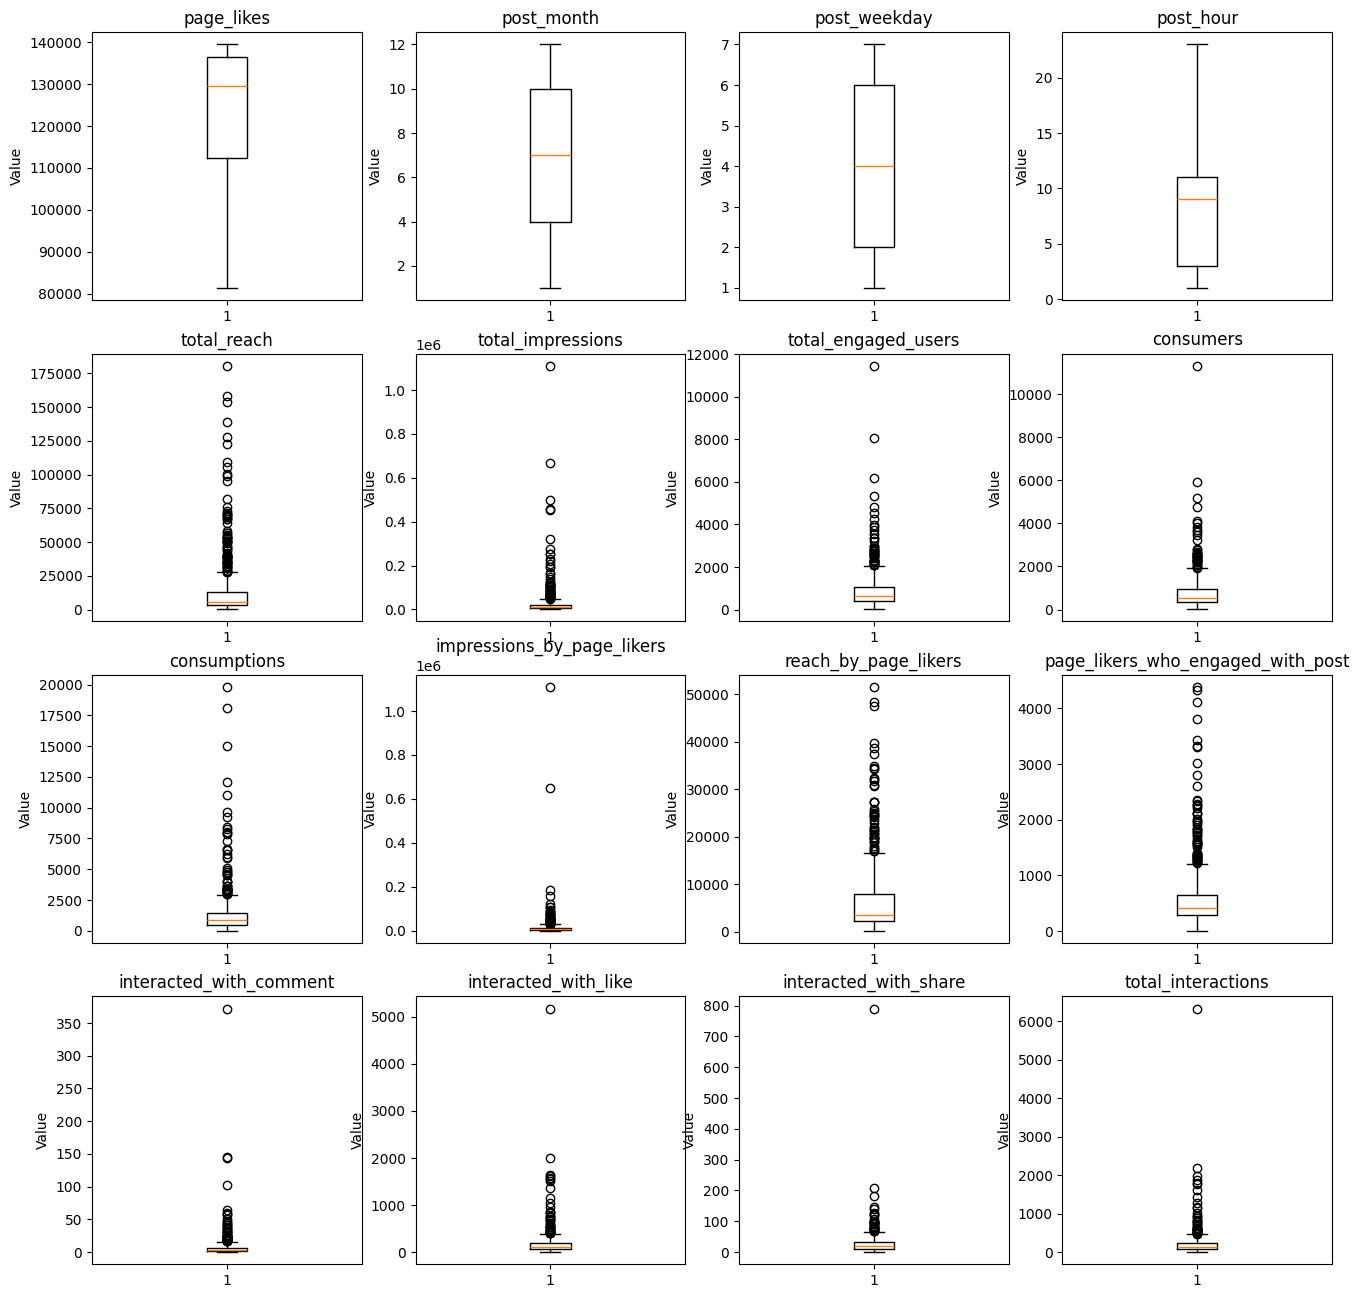

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(df_num.columns.to_list()):
    axes[i].boxplot(df_num[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

### Histograms

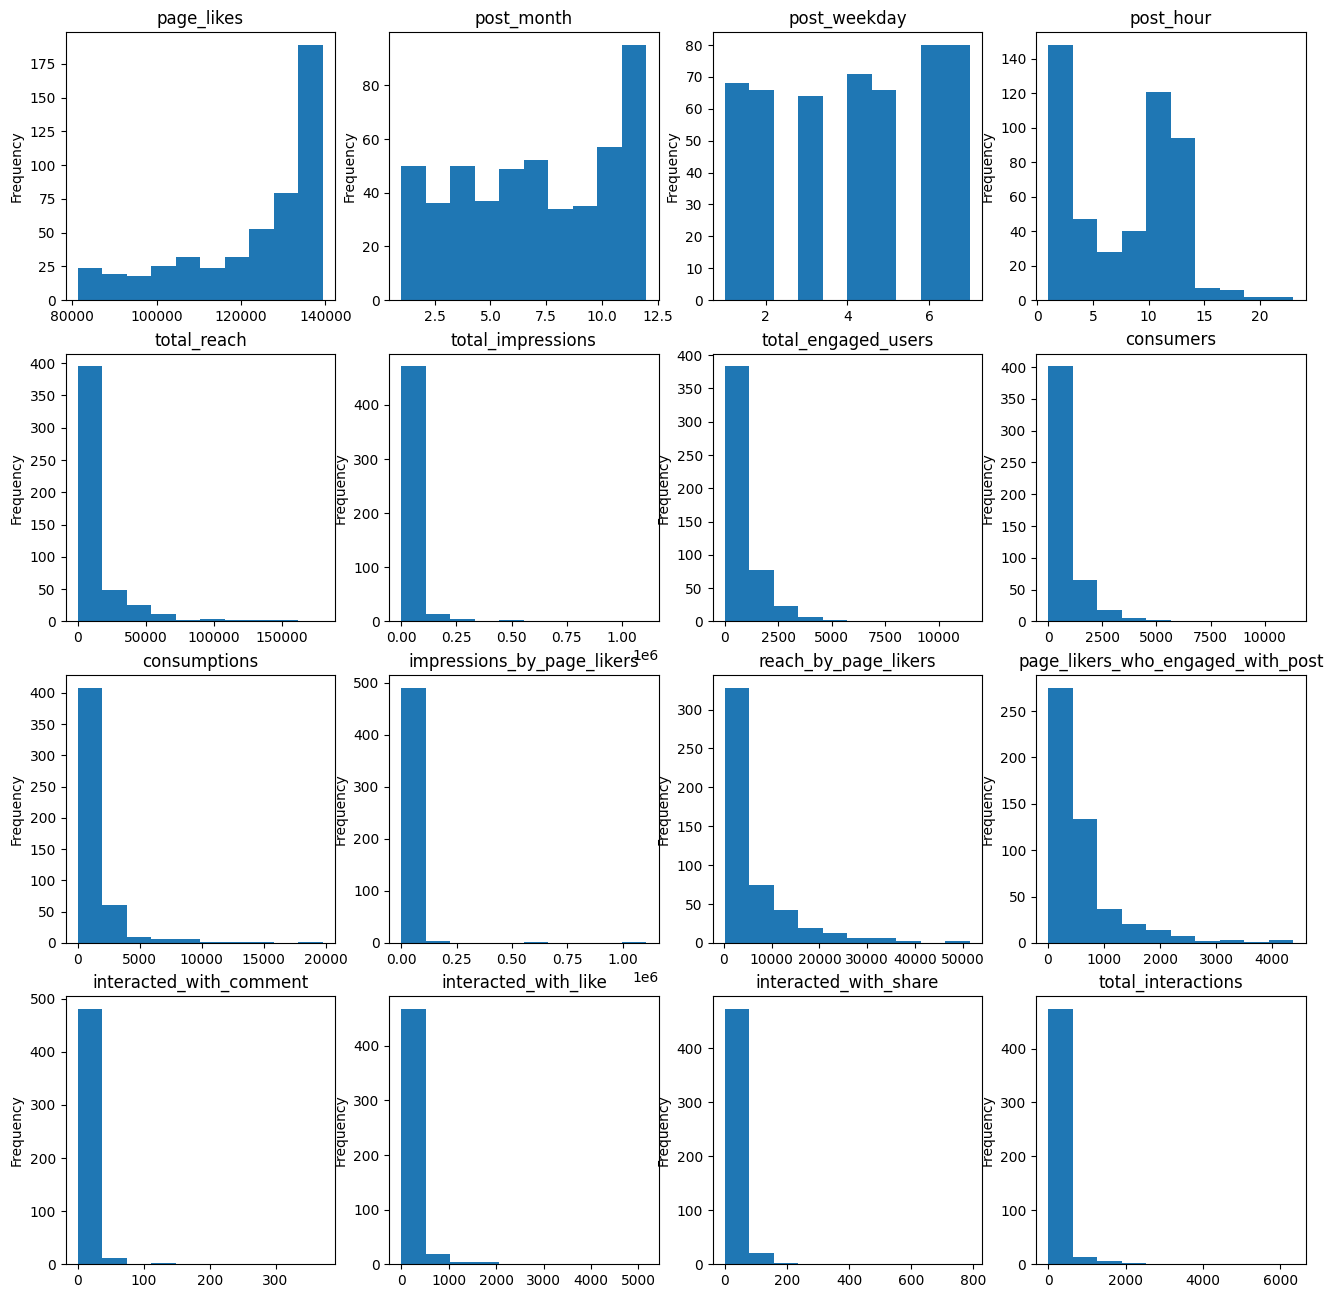

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(df_num.columns.to_list()):
    axes[i].hist(df_num[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')

### Observations

1. `page_likes` - Significant left skew, so consider log transform.
    * Tells us that we dealing with posts on pages that have a minimum of 81K likes and up to 139K likes.
    * That observation confirms that we're looking at data a relatively popular cosmetics brand. 
3. `post_month`
    * Range is as expected (1-12).
    * Data is mostly uniform, which uptick during last month (December).
5. `post_weekday` - same observations as `post_month` with the range of (1-7)
6. `post_hour`
    * Data is a little strange because the range is (1-23), so one hour is missing, which could be a data quality issue.
    * Otherwise it looks rather right skewed.
8. All remaining columns (listed below) are extremely right skewed, so a log transform is highly recommended.
    * As expected, there is a dropoff in magnitude of `impressions/reach` when comparing the whole population to just the subgroup of people who have liked the page.
    * For `reach`, the standard deviation for the total group is much greater than that of the subgroup, but for `impresssions` the standard deviation is similar for both groups.
    * The mean of `Consumptions` > `Engaged Users` > `Consumers`, which makes sense because one user can consume a post multiple times, each time counting as another consumption. Also, engagement is defined as all types of interactions with post, whereas consumption is a subset of interactions.
    * The mean of `Engaged users` > `People who have liked your Page and engaged with your post`, which makes sense because the latter is a subset of the former.
    * In the cell below, by comparing descriptive stats of the `total_interactions` column with the sum of the three interactions columns (comment, like, and share), we see that the sum is equivalent to the total column, which is to be expected.
    * Columns
      1. `total_reach`
      2. `total_impressions`
      3. `total_engaged_users`
      4. `consumers`
      5. `consumptions`
      6. `impressions_by_page_likers`
      7. `reach_by_page_likers`
      8. `page_likers_who_engaged_with_post`
      9. `interacted_with_comment`
      10. `interacted_with_like`
      11. `interacted_with_share`
      12. `total_interactions`


In [17]:
df_interact = pd.DataFrame()
df_interact['sum'] = df[[
    'interacted_with_comment',
    'interacted_with_like',
    'interacted_with_share'
]].sum(axis=1)

df_interact['total_interactions'] = df['total_interactions']
df_interact.describe()

,sum,total_interactions
count,495.000000,495.000000
mean,213.967677,213.967677
std,381.677449,381.677449
min,0.000000,0.000000
25%,72.000000,72.000000
50%,125.000000,125.000000
75%,231.000000,231.000000
max,6334.000000,6334.000000


## Apply log transform

* Here we apply a log tranform to our highly skewed columns in the hopes of getting closer to a normal distribution.
* Except for the first column, `page_likes`, this tranform is successful.
* We'll keep `page_likes` as it.

In [18]:
columns_to_transform = [
    'page_likes',
    'total_reach',
    'total_impressions',
    'total_engaged_users',
    'consumers',
    'consumptions',
    'impressions_by_page_likers',
    'reach_by_page_likers',
    'page_likers_who_engaged_with_post',
]
df_num_log = pd.DataFrame()

for col in columns_to_transform:
    df_num_log[f'log_{col}'] = np.log(df_num[col])

df_num_log.head()

,log_page_likes,log_total_reach,log_total_impressions,log_total_engaged_users,log_consumers,log_consumptions,log_impressions_by_page_likers,log_reach_by_page_likers,log_page_likers_who_engaged_with_post
0,11.845397,7.920083,8.535230,5.181784,4.691348,5.068904,8.032035,7.402452,4.779123
1,11.845397,9.255314,9.855190,7.284135,7.215975,7.422971,9.368198,8.718009,7.010312
2,11.845397,7.788626,8.383205,5.176150,4.727388,5.036953,7.941651,7.315218,4.882802
3,11.845397,10.822335,11.384990,7.701200,6.672033,7.020191,11.019072,10.374990,7.234177
4,11.845397,8.887929,9.517384,6.508769,6.016157,6.363028,8.736811,8.070906,5.981414


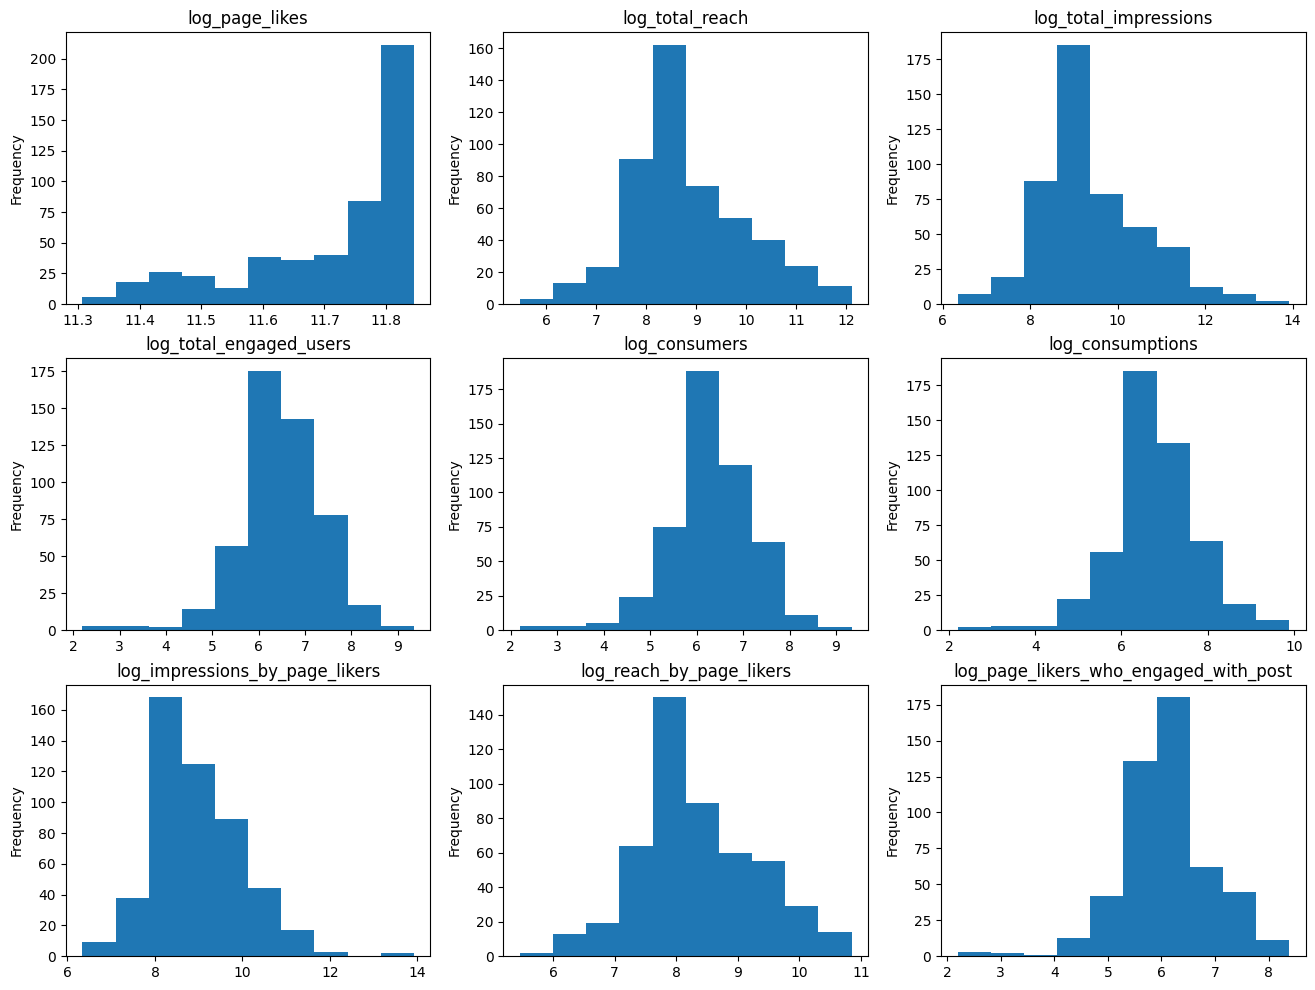

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df_num_log.columns.to_list()):
    axes[i].hist(df_num_log[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')

## Examine categorical columns



### Post type column

Because `post_type` is a categorial variable, we can't compute the mean, standard deviation, or other descriptive statistics, but we can look at the percent breakdown of values using `df.value_counts()`.

In [20]:
type_breakdown = df['post_type'].value_counts() / df.shape[0] * 100
type_breakdown

post_type
Photo     85.050505
Status     9.090909
Link       4.444444
Video      1.414141
Name: count, dtype: float64

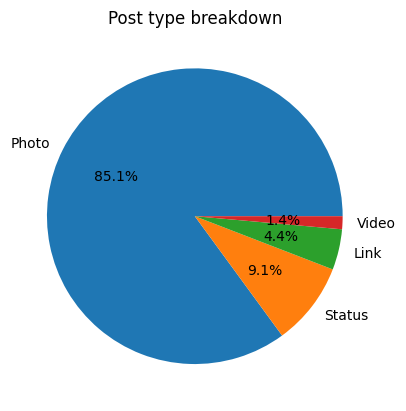

In [21]:
_ = type_breakdown.plot.pie(autopct='%1.1f%%')
_ = plt.title('Post type breakdown')

### Post category column

* The following figure from the research paper sheds light on the meaning of the integer values in the `post_category` column.
* The categories are indentified as the different types of advertizing strategy, such as action, product, and inspiration.

![Figure](../docs/4-Table3-1.png)

In [22]:
category_breakdown = df['post_category'].value_counts().sort_index()
category_breakdown

post_category
1    211
2    129
3    155
Name: count, dtype: int64

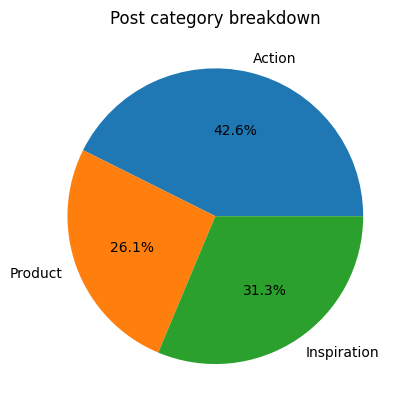

In [23]:
_ = category_breakdown.plot.pie(labels=['Action', 'Product', 'Inspiration'], autopct='%1.1f%%')
_ = plt.title('Post category breakdown')

### Paid post column

* The `paid_post` column is contains binarydata, where 0 means the company didn't pay Facebook to advertise the post, and 1 means they did pay. Our `df.describe()` and `df.value_counts()` both show that 72% of the posts in the dataset were unpaid and 28% were paid.

In [24]:
df['paid_post'].describe()

count    495.000000
mean       0.280808
std        0.449849
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: paid_post, dtype: float64

In [25]:
df['paid_post'].value_counts() / df.shape[0] * 100

paid_post
0.0    71.919192
1.0    28.080808
Name: count, dtype: float64

## Correlation heatmap plot

* Here we compare the correlations between our columns

In [33]:
df_complete = pd.concat([
    df[[
        'page_likes',
        'post_type',
        'post_category',
        'post_month',
        'post_weekday',
        'post_hour',
        'paid_post',
    ]],
    df_num_log[[
        'log_total_reach',
        'log_total_impressions',
        'log_total_engaged_users',
        'log_consumers',
        'log_consumptions',
        'log_impressions_by_page_likers',
        'log_reach_by_page_likers',
        'log_page_likers_who_engaged_with_post',
    ]],
    df[[
        'interacted_with_comment',
        'interacted_with_like',
        'interacted_with_share',
        'total_interactions',
    ]]],
    axis=1
)
df_complete.head()

,page_likes,post_type,post_category,post_month,post_weekday,post_hour,paid_post,log_total_reach,log_total_impressions,log_total_engaged_users,log_consumers,log_consumptions,log_impressions_by_page_likers,log_reach_by_page_likers,log_page_likers_who_engaged_with_post,interacted_with_comment,interacted_with_like,interacted_with_share,total_interactions
0,139441,Photo,2,12,4,3,0.0,7.920083,8.535230,5.181784,4.691348,5.068904,8.032035,7.402452,4.779123,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,9.255314,9.855190,7.284135,7.215975,7.422971,9.368198,8.718009,7.010312,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,7.788626,8.383205,5.176150,4.727388,5.036953,7.941651,7.315218,4.882802,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,10.822335,11.384990,7.701200,6.672033,7.020191,11.019072,10.374990,7.234177,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,8.887929,9.517384,6.508769,6.016157,6.363028,8.736811,8.070906,5.981414,19,325.0,49.0,393


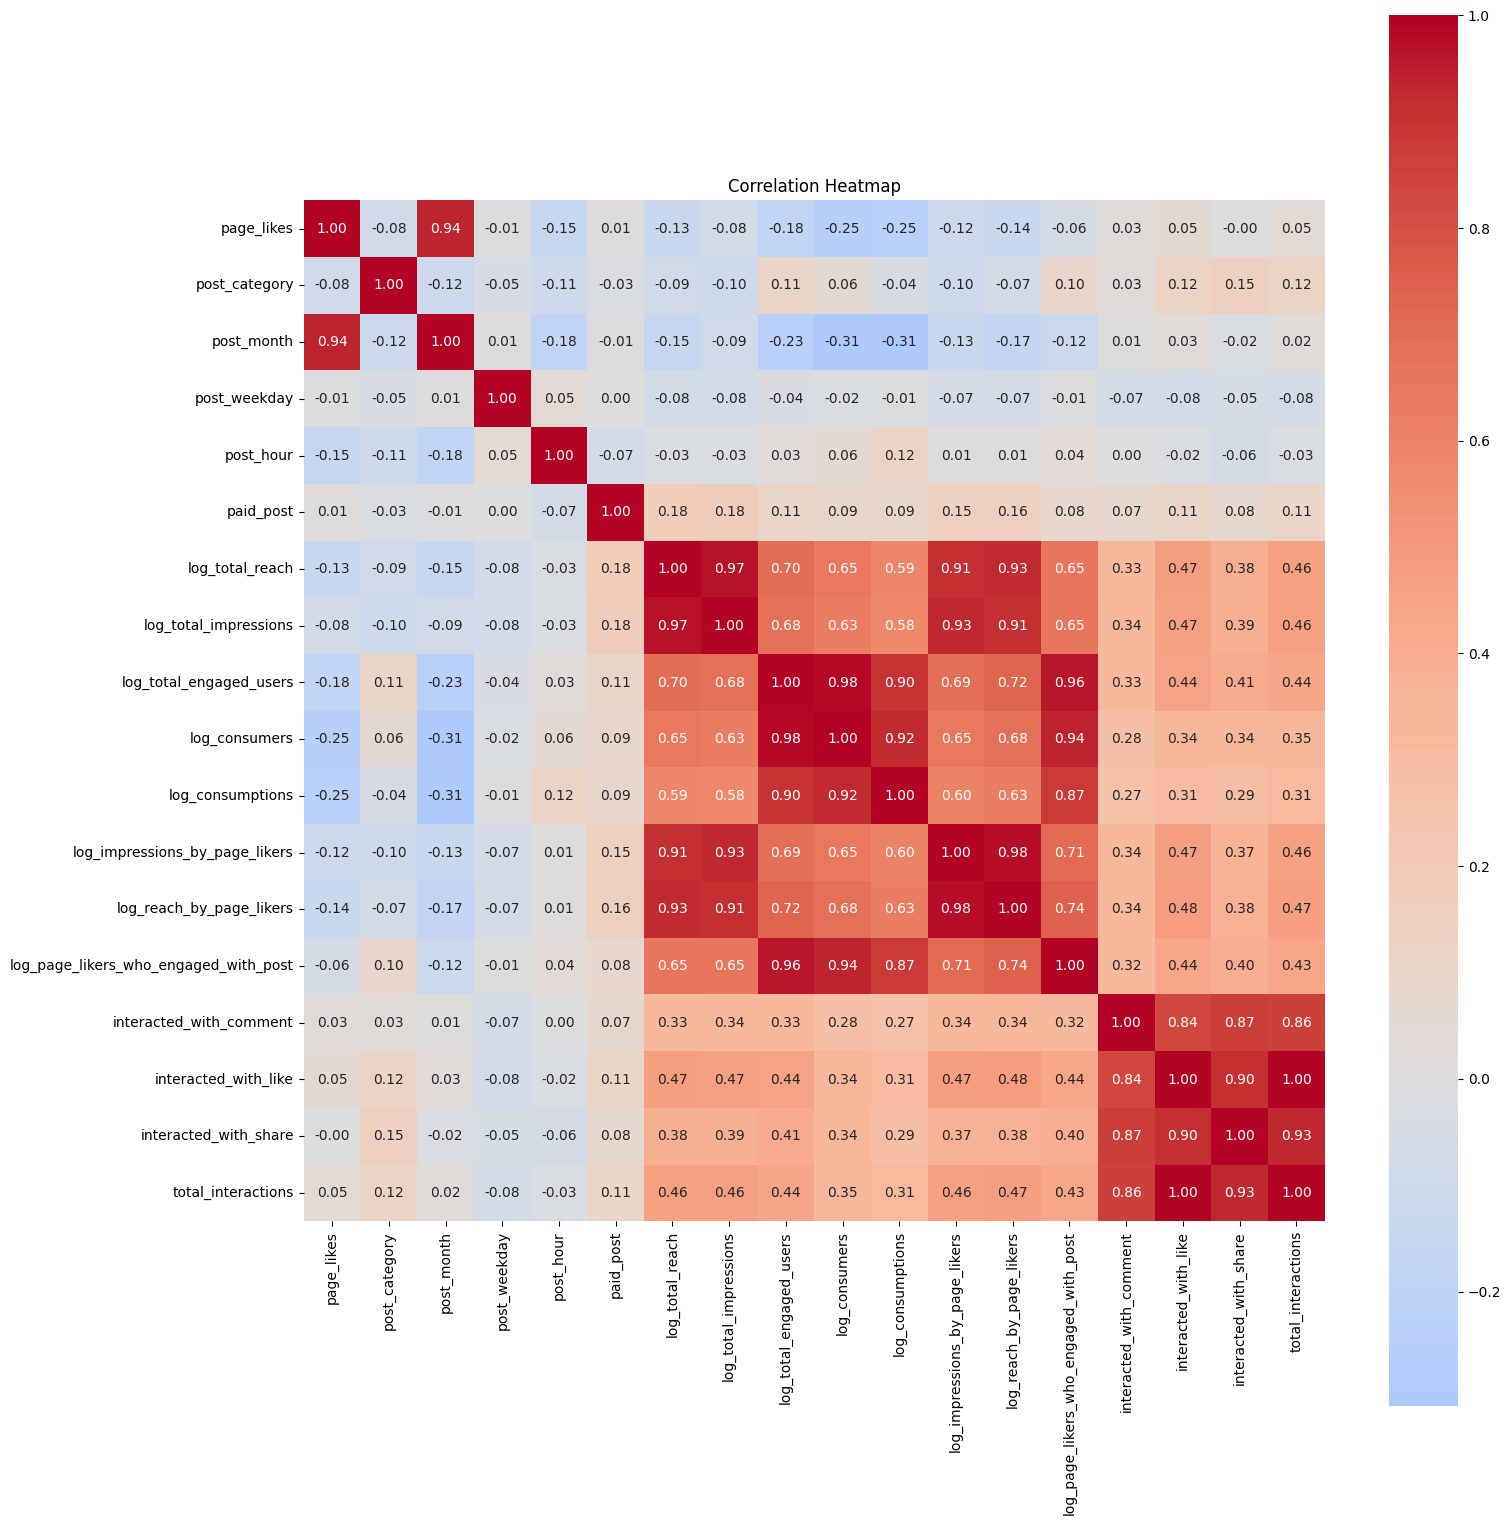

In [32]:
corr = df_complete.corr(numeric_only=True)

plt.figure(figsize=(16, 16))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

* Since there are mulitple choices 